In [1]:
import os
import pandas as pd
import xara
import veux
import numpy as np
from pprint import pprint

from functions import add_nodes, add_materials, add_sections, build_model
from units import *

import matplotlib.pyplot as plt
from plotting import *

from ReadRecord import ReadRecord

In [2]:
# Take excel file and process nodes and elements.
cwd = os.getcwd()
model_geometry_xls = os.path.join(cwd, 'examples', 'MLK', 'model_geometry.xlsx')

nodes_df = pd.read_excel(model_geometry_xls, sheet_name='nodeInfo')
elements_df = pd.read_excel(model_geometry_xls, sheet_name='elements')

model = xara.Model(ndm=3, ndf=6)

# Add nodes to the model
add_nodes(model, nodes_df)

# Add materials to the model
add_materials(model)

# Add section geometries to model
add_sections(model, plot=False)

# Add elements to the model
build_model(model, elements_df)

#model.print()

Fixing Node: 10
Fixing Node: 110
Fixing Node: 210
Fixing Node: 310
Fixing Node: 410
Fixing Node: 510
Fixing Node: 610
Fixing Node: 710
Fixing Node: 810
Fixing Node: 910
Fixing Node: 1010
Fixing Node: 1110
Fixing Node: 1210
Fixing Node: 1310
Fixing Node: 1410
Fixing Node: 1510
Fixing Node: 1610
Fixing Node: 1710
Fixing Node: 1810
Fixing Node: 1910
Fixing Node: 2010
Fixing Node: 2110
Fixing Node: 2210
Fixing Node: 2310
Fixing Node: 2410
Fixing Node: 2510
Fixing Node: 2610
Fixing Node: 2710
Fixing Node: 2810
Fixing Node: 2910
Fixing Node: 3010
Fixing Node: 3110
Fixing Node: 3210
Fixing Node: 3310
Fixing Node: 3410
Fixing Node: 3510
Fixing Node: 3610
Fixing Node: 3710
Fixing Node: 3810
Fixing Node: 3910
Fixing Node: 4010
Fixing Node: 4110
Fixing Node: 4210
Fixing Node: 4310
Fixing Node: 4410
Fixing Node: 4510
Fixing Node: 4610
Fixing Node: 4710
Fixing Node: 4810
Fixing Node: 4910
Fixing Node: 5010
Fixing Node: 5110
Fixing Node: 5210
Fixing Node: 5310
Fixing Node: 5410
Fixing Node: 5510
Fix

In [3]:
# Do EigenValue Analysis for structural model
numEigen = 5
option = "-genBandArpack" 
eigenValues = model.eigen(option, numEigen)

# print("eigen values at start of transient:",eigenValues)
T = 2 * np.pi / np.sqrt(np.array(eigenValues))
print('Periods of identified modes:', T)

# plot_mode(model, numEigen)

Periods of identified modes: [0.3980674  0.35021422 0.34645578 0.33278158 0.32589112]


In [4]:
mass_matrix = model.getTangent(m=1, c=0, k=0)
total_mass = sum(sum(mass_matrix))/3
print("Total weight of the structure:", total_mass*g, "kips")

Total weight of the structure: 20842.061652858007 kips


In [5]:
top_of_col_nodes = nodes_df[nodes_df['desc']=='top of column']['nodeID'].tolist()
# print("Top of column nodes:", top_of_col_nodes)
# Count number of top of column nodes
num_top_nodes = len(top_of_col_nodes)
print("Number of top of column nodes:", num_top_nodes)

Number of top of column nodes: 65


In [6]:
# Start of analysis generation

# Create the system of equation, a sparse solver with partial pivoting
model.system('BandGeneral')

# Create the constraint handler, the transformation method
model.constraints('Transformation')

# Create the DOF numberer, the reverse Cuthill-McKee algorithm
model.numberer('RCM')

# Create the convergence test, the norm of the residual with a tolerance of
# 1e-12 and a max number of iterations of 10
model.test('RelativeNormDispIncr', 1.0e-12, 50, 1)

# Create the solution algorithm, a Newton-Raphson algorithm
model.algorithm('Newton')

# Create the integration scheme, the LoadControl scheme using steps of 0.1
model.integrator('LoadControl', 0.1)

# Create the analysis object
model.analysis('Static')

# Add axial load to the columns
P = total_mass*g/65;  # Split weight of the structure as axial load to columns

# Create a Plain load pattern with a Linear TimeSeries
model.timeSeries('Linear', 1)
model.pattern('Plain', 1, 1)

# Create nodal loads at nodes 3 & 4
#    nd  FX,  FY, MZ
for node in top_of_col_nodes:
    model.load(node, *[0.0, 0.0, -P, 0.0, 0.0, 0.0])

# Perform the static analysis
model.analyze(10)
# plot_deformed_state(model, scale=100)  # scale in in
print("Gravity load analysis completed.")

# plot_deformed_state(model, scale=100)  # scale in in

   ITERATE :: Iter:     1 |dR|/|dR1|:           1
   ITERATE :: Iter:     2 |dR|/|dR1|: 0.000323944
   ITERATE :: Iter:     3 |dR|/|dR1|: 3.46025e-11
   ITERATE :: Iter:     4 |dR|/|dR1|: 3.26388e-15

   ITERATE :: Iter:     1 |dR|/|dR1|:           1
   ITERATE :: Iter:     2 |dR|/|dR1|: 0.000324368
   ITERATE :: Iter:     3 |dR|/|dR1|: 3.47399e-11
   ITERATE :: Iter:     4 |dR|/|dR1|: 2.69433e-15

   ITERATE :: Iter:     1 |dR|/|dR1|:           1
   ITERATE :: Iter:     2 |dR|/|dR1|: 0.000324793
   ITERATE :: Iter:     3 |dR|/|dR1|: 3.48781e-11
   ITERATE :: Iter:     4 |dR|/|dR1|: 2.74541e-15

   ITERATE :: Iter:     1 |dR|/|dR1|:           1
   ITERATE :: Iter:     2 |dR|/|dR1|: 0.000325219
   ITERATE :: Iter:     3 |dR|/|dR1|: 3.50166e-11
   ITERATE :: Iter:     4 |dR|/|dR1|: 2.84925e-15

   ITERATE :: Iter:     1 |dR|/|dR1|:           1
   ITERATE :: Iter:     2 |dR|/|dR1|: 0.000325646
   ITERATE :: Iter:     3 |dR|/|dR1|: 3.51561e-11
   ITERATE :: Iter:     4 |dR|/|dR1|: 3.41749e

In [7]:
# Add rayleigh damping
zeta1 = zeta2 = 0.02
T1 = T[0]
T2 = 0.1*T1

omega1 = 2 * np.pi / T1
omega2 = 2 * np.pi / T2

# Compute the rayleigh damping coefficients
a0 = 2 * zeta1 * omega1 * omega2 / (omega1 + omega2)
a1 = 2 * zeta1 / (omega1 + omega2)

print("Rayleigh Damping Coefficients:")
print(f"a0: {a0}, a1: {a1}")

Rayleigh Damping Coefficients:
a0: 0.5739718110833872, a1: 0.00023037961517498106


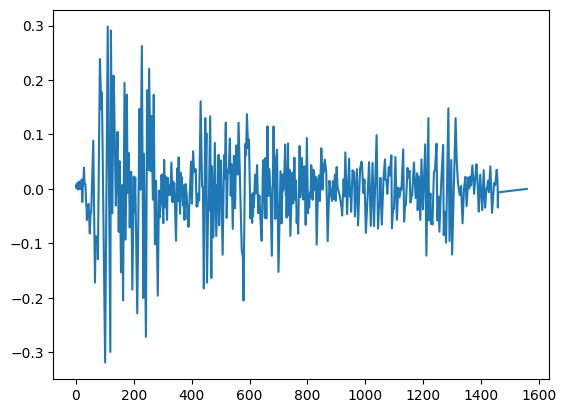

In [8]:
# Set some parameters
record = 'elCentro'

# Permform the conversion from SMD record to OpenSees record
dt, nPts, values = ReadRecord(record+'.at2')

plt.plot(values)

In [9]:
print(g)


386.0


eigen values at start of transient: [247.7246697756383, 320.2392946755973]
   ITERATE :: Iter:     1, Norm: 2.65064e-17, Norm deltaR: 1.23152e-10

   ITERATE :: Iter:     1, Norm: 2.66445e-17, Norm deltaR: 1.13673e-10

   ITERATE :: Iter:     1, Norm: 2.69499e-17, Norm deltaR: 1.23929e-10

   ITERATE :: Iter:     1, Norm: 2.66895e-17, Norm deltaR: 1.12828e-10

   ITERATE :: Iter:     1, Norm: 2.67466e-17, Norm deltaR:  1.2131e-10

   ITERATE :: Iter:     1, Norm: 2.65692e-17, Norm deltaR: 1.11359e-10

   ITERATE :: Iter:     1, Norm:   2.673e-17, Norm deltaR: 1.23121e-10

   ITERATE :: Iter:     1, Norm: 2.67277e-17, Norm deltaR: 1.11819e-10

   ITERATE :: Iter:     1, Norm: 2.65911e-17, Norm deltaR: 1.21694e-10

   ITERATE :: Iter:     1, Norm: 2.71356e-17, Norm deltaR: 1.12469e-10

   ITERATE :: Iter:     1, Norm: 2.65625e-17, Norm deltaR: 1.17577e-10

   ITERATE :: Iter:     1, Norm:  2.6865e-17, Norm deltaR: 1.04042e-10

   ITERATE :: Iter:     1, Norm: 2.67562e-17, Norm deltaR: 1.

Text(0.5, 1.0, 'Time History of Top of Column Displacement')

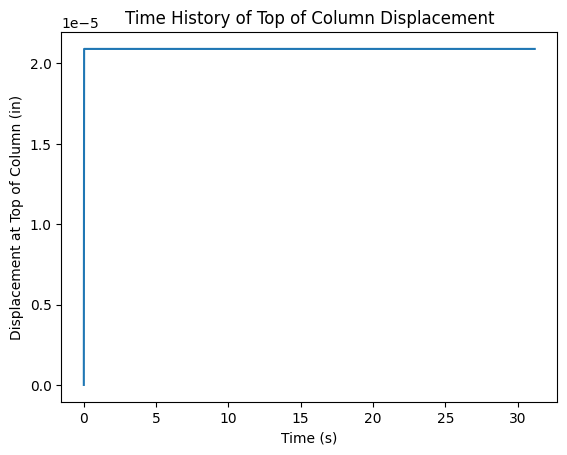

In [ ]:
model.loadConst('-time', 0.0)

# Set time series to be passed to uniform excitation
model.timeSeries('Path', 1, '-values', values, '-dt', dt, '-factor', 1.0*g)

# Create UniformExcitation load pattern // tag dir 
model.pattern('UniformExcitation', 2, 2, '-accel', 1)

#model.pattern('UniformExcitation', 3, 2, '-accel', 1)

# set the rayleigh damping factors for nodes & elements
model.rayleigh(a0, 0.0, a1, 0.0)

# Delete the old analysis and all it's component objects
model.wipeAnalysis()

# Create the system of equation, a banded general storage scheme
model.system('BandGeneral')

# Create the constraint handler, a plain handler as homogeneous boundary
model.constraints('Transformation')

# Create the convergence test, the norm of the residual with a tolerance of 
# 1e-12 and a max number of iterations of 10
model.test('NormDispIncr', 1.0e-12,  50, 1)

# Create the solution algorithm, a Newton-Raphson algorithm
model.algorithm('Newton')

# Create the DOF numberer, the reverse Cuthill-McKee algorithm
model.numberer('RCM')

# Create the integration scheme, the Newmark with alpha =0.5 and beta =.25
model.integrator('Newmark', 0.5, 0.25)

# Create the analysis object
model.analysis('Transient')

# Perform an eigenvalue analysis
numEigen = 2
eigenValues = model.eigen(numEigen)
print("eigen values at start of transient:", eigenValues)

# set some variables
tFinal = nPts*dt
tCurrent = model.getTime()
ok = 0

time = [tCurrent]
u3 = [0.0]

# Perform the transient analysis
while ok == 0 and tCurrent < tFinal:
    
    ok = model.analyze(1, dt)
    
    # if the analysis fails try initial tangent iteration
    if ok != 0:
        print("regular newton failed .. lets try an initail stiffness for this step")
        model.test('NormDispIncr', 1.0e-12,  50, 1)
        model.algorithm('ModifiedNewton', '-initial')
        ok = model.analyze(1, dt)

        if ok == 0:
            print("that worked .. back to regular newton")
        model.test('NormDispIncr', 1.0e-12,  50 , 1)
        model.algorithm('Newton')
    
    tCurrent = model.getTime()
    time.append(tCurrent)
    print("Current time:", tCurrent)
    u3.append(model.nodeDisp(top_of_col_nodes[0], 1))

plt.plot(time, u3)
plt.xlabel('Time (s)')
plt.ylabel('Displacement at Top of Column (in)')
plt.title('Time History of Top of Column Displacement')

In [11]:
u3

[0.0,
 2.090330655742463e-05,
 2.090330655742494e-05,
 2.0903306557425234e-05,
 2.090330655742553e-05,
 2.090330655742581e-05,
 2.0903306557426108e-05,
 2.090330655742639e-05,
 2.0903306557426677e-05,
 2.090330655742696e-05,
 2.090330655742725e-05,
 2.0903306557427534e-05,
 2.0903306557427822e-05,
 2.09033065574281e-05,
 2.0903306557428378e-05,
 2.090330655742866e-05,
 2.0903306557428984e-05,
 2.0903306557429276e-05,
 2.0903306557429564e-05,
 2.0903306557429892e-05,
 2.0903306557430184e-05,
 2.0903306557430465e-05,
 2.090330655743075e-05,
 2.0903306557431014e-05,
 2.0903306557431295e-05,
 2.090330655743157e-05,
 2.0903306557431885e-05,
 2.090330655743218e-05,
 2.0903306557432498e-05,
 2.09033065574328e-05,
 2.090330655743308e-05,
 2.0903306557433355e-05,
 2.0903306557433626e-05,
 2.09033065574339e-05,
 2.0903306557434212e-05,
 2.0903306557434504e-05,
 2.090330655743482e-05,
 2.090330655743511e-05,
 2.090330655743539e-05,
 2.0903306557435666e-05,
 2.090330655743594e-05,
 2.0903306557436

In [12]:
u3

[0.0,
 2.090330655742463e-05,
 2.090330655742494e-05,
 2.0903306557425234e-05,
 2.090330655742553e-05,
 2.090330655742581e-05,
 2.0903306557426108e-05,
 2.090330655742639e-05,
 2.0903306557426677e-05,
 2.090330655742696e-05,
 2.090330655742725e-05,
 2.0903306557427534e-05,
 2.0903306557427822e-05,
 2.09033065574281e-05,
 2.0903306557428378e-05,
 2.090330655742866e-05,
 2.0903306557428984e-05,
 2.0903306557429276e-05,
 2.0903306557429564e-05,
 2.0903306557429892e-05,
 2.0903306557430184e-05,
 2.0903306557430465e-05,
 2.090330655743075e-05,
 2.0903306557431014e-05,
 2.0903306557431295e-05,
 2.090330655743157e-05,
 2.0903306557431885e-05,
 2.090330655743218e-05,
 2.0903306557432498e-05,
 2.09033065574328e-05,
 2.090330655743308e-05,
 2.0903306557433355e-05,
 2.0903306557433626e-05,
 2.09033065574339e-05,
 2.0903306557434212e-05,
 2.0903306557434504e-05,
 2.090330655743482e-05,
 2.090330655743511e-05,
 2.090330655743539e-05,
 2.0903306557435666e-05,
 2.090330655743594e-05,
 2.0903306557436